# Dynamic Programming for Reinforcement Learning (Value Iteration on FrozenLake)

**Goal.** An optimal policy will be computed for the FrozenLake environment using **dynamic programming** (value iteration).  
Then its performance will be compared to a random policy and visualized.

**Key ideas.**

- The full transition model `P(s' , r | s, a)` is assumed to be known.
- The **Bellman optimality equation** is used:

$$
V^*(s) = \max_a \sum_{s', r} p(s', r \mid s, a)\,\left[ r + \gamma\, V^*(s') \right].
$$


- Value iteration is used to approximate \(V^\*\).
- A **greedy policy** is extracted from \(V^\*\).
- The policy is then evaluated by running episodes and measuring:
  - average return (total reward),
  - success rate (fraction of episodes that reach the goal).


<img src="dp_flow.png" width="700">


In [23]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# Gymnasium is preferred; gym is used as a fallback if needed.
try:
    import gymnasium as gym
except ImportError:
    import gym

np.set_printoptions(precision=3, suppress=True)


In [24]:
# %%
# 4x4 FrozenLake with or without slipperiness
env = gym.make("FrozenLake-v1", is_slippery=False)  # set to True to show stochasticity

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

# The transition model is stored in env.P:
# env.P[s][a] -> list of (prob, next_state, reward, done)
print("Example transitions from state 0, action 1 (DOWN):")
for prob, next_s, reward, done in env.P[0][1]:
    print(f"  prob={prob}, next_state={next_s}, reward={reward}, done={done}")


Number of states: 16
Number of actions: 4
Example transitions from state 0, action 1 (DOWN):
  prob=1.0, next_state=4, reward=0.0, done=False


a:\anaconda3_23.7.3\envs\mitocluster\Lib\site-packages\gymnasium\core.py:311: UserWarning: WARN: env.P to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.P` for environment variables or `env.get_wrapper_attr('P')` that will search the reminding wrappers.
  logger.warn(


In [26]:
# %%
# Map characters: S=start, F=frozen, H=hole, G=goal
desc = env.unwrapped.desc.astype(str)

print("FrozenLake map:")
for row in desc:
    print(" ".join(row))

action_names = {
    0: "LEFT",
    1: "DOWN",
    2: "RIGHT",
    3: "UP",
}
print("\nAction mapping:", action_names)


FrozenLake map:
S F F F
F H F H
F F F H
H F F G

Action mapping: {0: 'LEFT', 1: 'DOWN', 2: 'RIGHT', 3: 'UP'}


In [ ]:
# Dynamic Programming core: value iteration and policy extraction
def value_iteration(env, gamma=0.99, theta=1e-8, max_iterations=1000):
    # Convergence threshold is theta
    # Difference betweeen V and the old V is the delta V
    """
    Value iteration for a finite MDP with known env.P.

    Returns:
        V       : optimal state-value function (shape: [n_states])
        history : list of max |ΔV| per iteration (for plotting convergence)
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    V = np.zeros(n_states)
    deltas = []

    for it in range(max_iterations):
        delta = 0.0
        V_new = np.copy(V)

        for s in range(n_states):
            # Skip terminal states if environment encodes them
            # (FrozenLake does not require special handling here, but it is fine.)
            action_values = []

            for a in range(n_actions):
                q_sa = 0.0
                for prob, next_s, reward, done in env.P[s][a]:
                    # Terminal states contribute only immediate reward
                    if done:
                        q_sa += prob * reward
                    else:
                        q_sa += prob * (reward + gamma * V[next_s])
                action_values.append(q_sa)

            V_new[s] = max(action_values)

        delta = np.max(np.abs(V_new - V))
        deltas.append(delta)
        V = V_new

        if delta < theta:
            print(f"Converged at iteration {it} with delta={delta:.2e}")
            break
    else:
        print("Maximum iterations reached without full convergence.")

    return V, deltas

V_star, deltas = value_iteration(env, gamma=0.99)

print("Optimal value function V*:")
print(V_star.reshape(int(np.sqrt(n_states)), -1))


Converged at iteration 6 with delta=0.00e+00
Optimal value function V*:
[[0.951 0.961 0.97  0.961]
 [0.961 0.    0.98  0.   ]
 [0.97  0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]


In [27]:
# Greedy policy from a value function
def greedy_policy_from_values(env, V, gamma=0.99):
    """
    Greedy policy w.r.t. state-value function V.
    π(s) = argmax_a Σ_{s',r} p(s',r|s,a) [ r + γ V(s') ].
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    policy = np.zeros(n_states, dtype=int)

    for s in range(n_states):
        action_values = np.zeros(n_actions)
        for a in range(n_actions):
            q_sa = 0.0
            for prob, next_s, reward, done in env.P[s][a]:
                if done:
                    q_sa += prob * reward
                else:
                    q_sa += prob * (reward + gamma * V[next_s])
            action_values[a] = q_sa
        best_a = np.argmax(action_values)
        policy[s] = best_a

    return policy

optimal_policy = greedy_policy_from_values(env, V_star)
print("Optimal policy (as action indices):")
print(optimal_policy.reshape(int(np.sqrt(n_states)), -1))


Optimal policy (as action indices):
[[1 2 1 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]


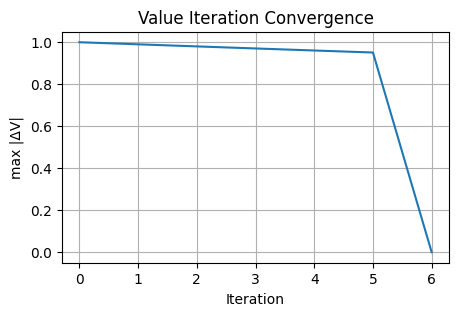

In [ ]:
# Convergence plot of value iteration
plt.figure(figsize=(5, 3))
plt.plot(deltas)
plt.xlabel("Iteration")
plt.ylabel("max |ΔV|")
plt.title("Value Iteration Convergence")
plt.grid(True)
plt.show()


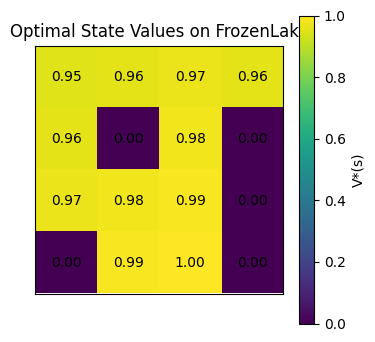

In [ ]:
# Heatmap of state values
side = int(np.sqrt(n_states))
V_grid = V_star.reshape(side, side)

plt.figure(figsize=(4, 4))
plt.imshow(V_grid, origin="upper")
plt.colorbar(label="V*(s)")
plt.title("Optimal State Values on FrozenLake")
for i in range(side):
    for j in range(side):
        plt.text(j, i, f"{V_grid[i, j]:.2f}", ha="center", va="center")
plt.xticks([])
plt.yticks([])
plt.show()


In [ ]:
# Policy arrows overlaying the map
arrow_symbols = {
    0: "←",  # LEFT
    1: "↓",  # DOWN
    2: "→",  # RIGHT
    3: "↑",  # UP
}

policy_grid = optimal_policy.reshape(side, side)

print("Map with optimal policy (arrows) per cell:\n")
for i in range(side):
    row_str = []
    for j in range(side):
        idx = i * side + j
        cell = desc[i, j]  # 'S','F','H','G'
        if cell in ["H", "G"]:
            row_str.append(cell)
        else:
            arrow = arrow_symbols[policy_grid[i, j]]
            row_str.append(arrow)
    print(" ".join(row_str))


Map with optimal policy (arrows) per cell:

↓ → ↓ ←
↓ H ↓ H
→ ↓ ↓ H
H → → G


In [ ]:
# Benchmark: random policy vs optimal policy
# Environment step/reset helpers (Gym vs Gymnasium)
def reset_env(env, seed=None):
    out = env.reset(seed=seed) if seed is not None else env.reset()
    # Gymnasium returns (obs, info), gym returns obs
    if isinstance(out, tuple):
        state, info = out
        return state
    else:
        return out

def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        next_state, reward, terminated, truncated, info = out
        done = terminated or truncated
    else:
        next_state, reward, done, info = out
    return next_state, reward, done, info


In [ ]:
# Episode runner and evaluation function
def run_episode(env, policy=None, max_steps=100):
    """
    Runs one episode following the given policy (if None, random actions are used).
    Returns total reward and whether the goal was reached.
    """
    state = reset_env(env)
    total_reward = 0.0
    success = False

    for _ in range(max_steps):
        if policy is None:
            action = env.action_space.sample()
        else:
            action = policy[state]

        next_state, reward, done, info = step_env(env, action)
        total_reward += reward

        if done:
            if reward > 0:
                success = True
            break

        state = next_state

    return total_reward, success

def evaluate_policy(env, policy, n_episodes=500):
    rewards = []
    successes = 0
    for _ in range(n_episodes):
        R, success = run_episode(env, policy)
        rewards.append(R)
        if success:
            successes += 1
    avg_reward = np.mean(rewards)
    success_rate = successes / n_episodes
    return avg_reward, success_rate


In [ ]:
# Run the benchmark
n_eval_episodes = 500

# Random policy (baseline)
avg_r_random, sr_random = evaluate_policy(env, policy=None, n_episodes=n_eval_episodes)

# Optimal policy from value iteration
avg_r_opt, sr_opt = evaluate_policy(env, policy=optimal_policy, n_episodes=n_eval_episodes)

print(f"Random policy:  avg reward = {avg_r_random:.3f}, success rate = {sr_random*100:.1f}%")
print(f"Optimal policy: avg reward = {avg_r_opt:.3f}, success rate = {sr_opt*100:.1f}%")


Random policy:  avg reward = 0.016, success rate = 1.6%
Optimal policy: avg reward = 1.000, success rate = 100.0%


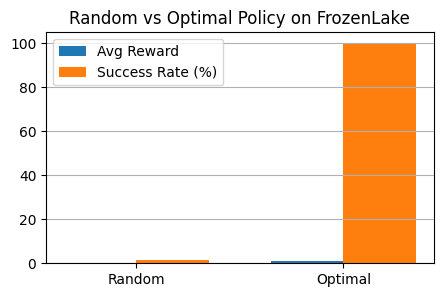

In [22]:
# 6.4. Simple bar chart for comparison
labels = ["Random", "Optimal"]
avg_rewards = [avg_r_random, avg_r_opt]
success_rates = [sr_random * 100, sr_opt * 100]

plt.figure(figsize=(5, 3))
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, avg_rewards, width, label="Avg Reward")
plt.bar(x + width/2, success_rates, width, label="Success Rate (%)")

plt.xticks(x, labels)
plt.title("Random vs Optimal Policy on FrozenLake")
plt.legend()
plt.grid(axis="y")
plt.show()
